In [217]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [218]:
df = pd.read_csv('source/FReDA4.csv')

In [219]:
o = df['Relationship Length (years)'].quantile(0.15)
p = df['Relationship Length (years)'].quantile(0.50)
q = df['Relationship Length (years)'].quantile(0.75)

In [220]:
def len_to_bins(val):
    if val <= 2.5:
        return "Short (2.5 years)"
    elif val <= 10:
        return "Medium (10 years)"
    else:
        return "Long (10+ years)"

df['Relationship Length (bins)'] = df['Relationship Length (years)'].apply(len_to_bins)

In [221]:
df.rename(columns={'Relationship Length (years)':'Relationship_length_years'}, inplace=True)

In [222]:
import statsmodels.formula.api as smf

model = smf.ols('Frequency ~ Age * Relationship_length_years', data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Frequency   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     487.7
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          1.09e-300
Time:                        15:20:09   Log-Likelihood:                -21597.
No. Observations:               13314   AIC:                         4.320e+04
Df Residuals:                   13310   BIC:                         4.323e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

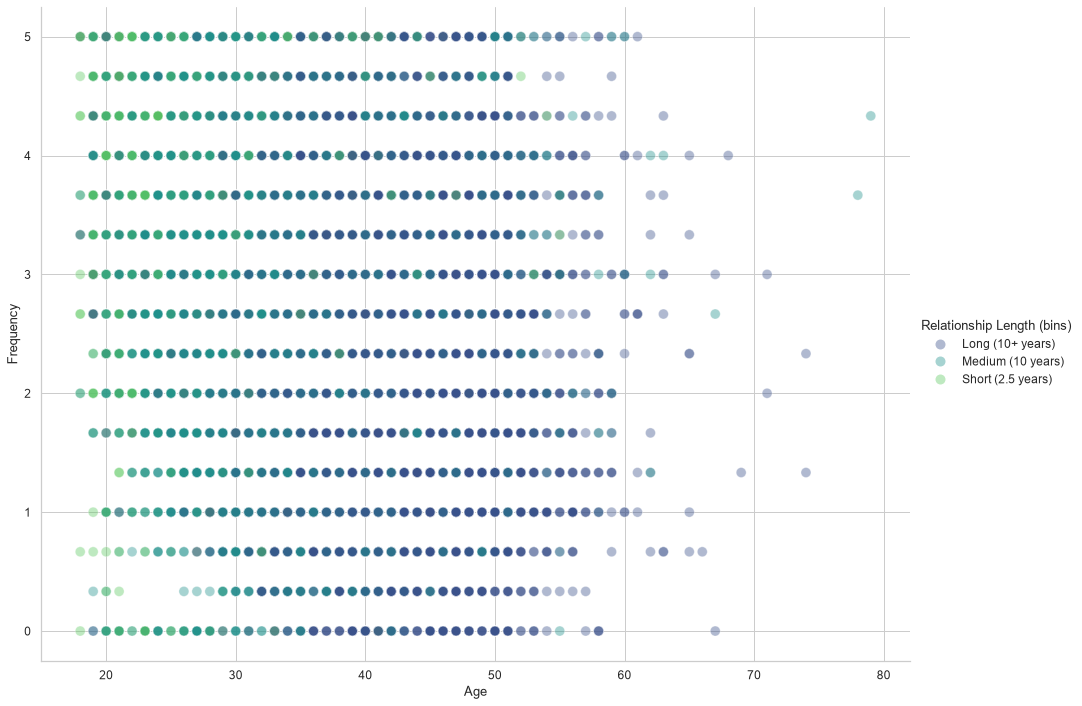

In [223]:
sns.set_theme(style="whitegrid", font_scale=1.1)

g = sns.relplot(
    data=df,
    x='Age',
    y='Frequency',
    hue='Relationship Length (bins)',
    palette='viridis',
    kind='scatter',
    height=10,
    aspect=1.3,
    alpha=0.4,
    s=100,
)
sns.despine()

plt.show()

In [224]:
pal = [
    '#C87A5E',
    '#6D947B',
    '#84739E'
]

order = [
    "Short (2.5 years)",
    "Medium (10 years)",
    "Long (10+ years)"
]


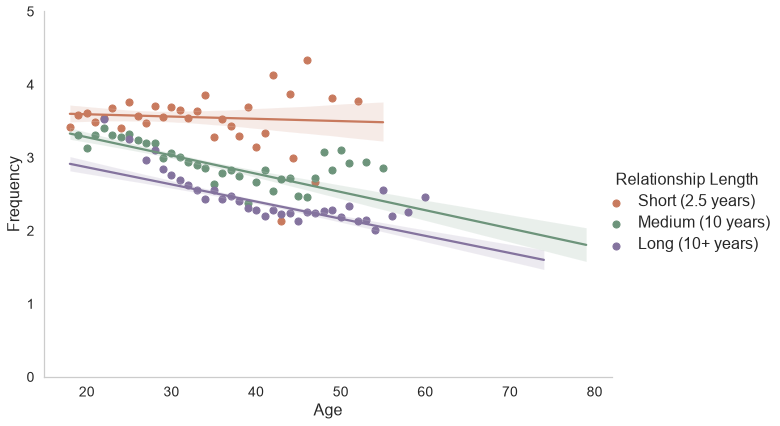

In [229]:


g = sns.lmplot(
    data=df,
    x="Age",
    x_ci=None,
    x_bins=200,
    y="Frequency",
    hue="Relationship Length (bins)",
    hue_order=order,
    palette=pal,

    height=6,
    aspect=1.5,

    # logx=True,
)

plt.xlabel("Age", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(False)

g._legend.set_title("Relationship Length")

plt.setp(g._legend.get_texts(), fontsize=16)
plt.setp(g._legend.get_title(), fontsize=16)

plt.ylim([0, 5])

plt.savefig(
    'output/img/paper/Age.png',
    dpi=600,
    transparent=False,
    bbox_inches='tight'
)

plt.show()